# **Estimación local de coeficientes aerodinámicos en dos cilindros circulares mediante probes de pared en LES-WALE**
---
## *Subcoordinación de Posgrado y Educación Continua.*
### [Instituto Mexicano de Tecnología del Agua](https://www.gob.mx/imta).<br>

<img src="./Datos/Imagenes/Logos.png" height="100" align="middle">

**Tutor: Dr. Ariosto Aguilar Chávez** <br>
**Tutorados: M. en C. Gibrán Mubarqui Guevara, Ing. Elizabeth Rosario Hernández Barrientos, Ing. Sebastian López Noriega, Ing. Omar Ulises Robles Pereyra**<br>


[![Open In Colab](./Datos/Imagenes/colab-badge.svg)](https://colab.research.google.com/github/OmarURP/Toolbox_publica/blob/main/09_DosPilas.ipynb)

---

In [1]:
# Carga de librerías
import ImtaTURB as imta
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Carga de datos
file_p = "Datos/OpenFOAM/20_cm/p"
file_U = "Datos/OpenFOAM/20_cm/U"
# Ventana de tiempo
inicio = 10 # Ignorando arranque en caliente
# Datos para cálculos
rho = 1000.0   # kg/m^3
D = 0.05       # m
R = D / 2      # m
span = 0.26    # m (altura de la pila)

In [3]:
# Procesar p
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)
U_probes, tiempo_U, coords_U, fs_U = imta.cargar_U_OpenFOAM(file_U)

Se extrajeron 168 probes.
Tiempo inicial: 0.00 s, tiempo final: 200.00 s
Duración de la muestra: 200.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)
Se extrajeron 168 probes.
Tiempo inicial: 0.00 s, tiempo final: 200.00 s
Duración de la muestra: 200.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


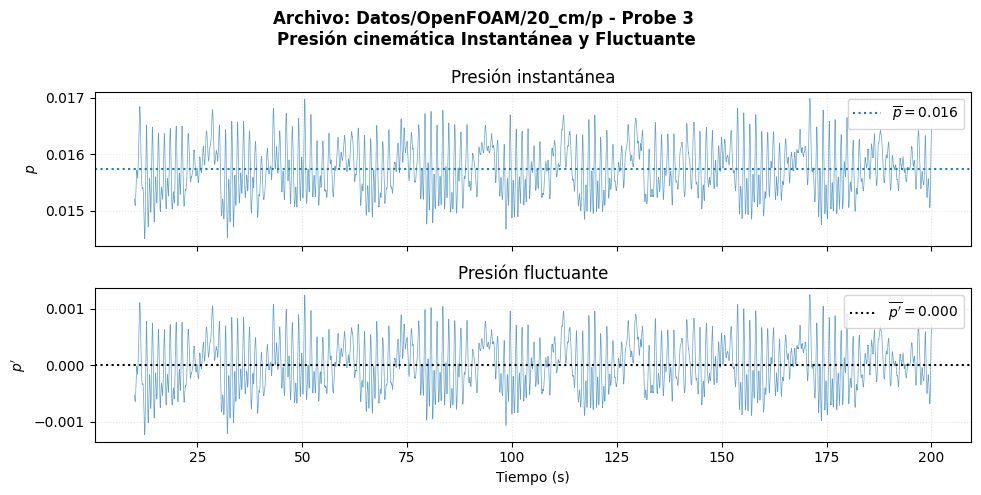

In [4]:
# Probe a visualizar
probe_1 = 0
# Visualización de señal de presión
p1, t1, _ = imta.recortar_tiempo(p_probes, probe=probe_1, inicio=inicio)
p1_fluc, _ = imta.fluctuante(p1, tiempo=t1)
probe_2 = 3
p2, t2, _ = imta.recortar_tiempo(p_probes, probe=probe_2, inicio=inicio)
p2_fluc, _ = imta.fluctuante(p2, tiempo=t2)
imta.plot_p(t1, p1_fluc,
            titulo=f'Archivo: {file_p} - Probe {probe_2} \nPresión cinemática Instantánea y Fluctuante',
            etiqueta='p');

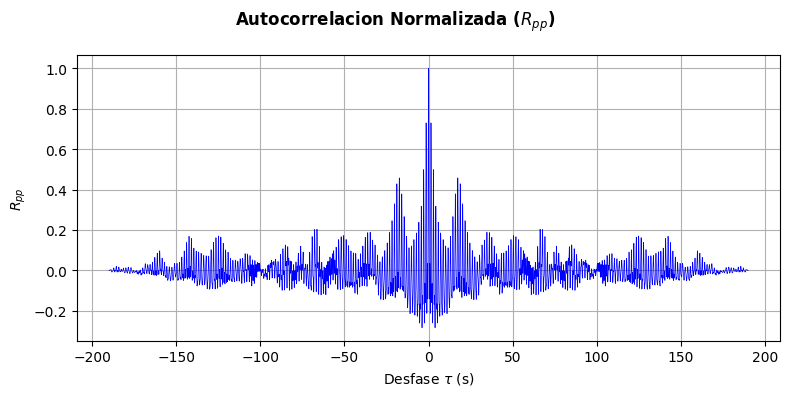

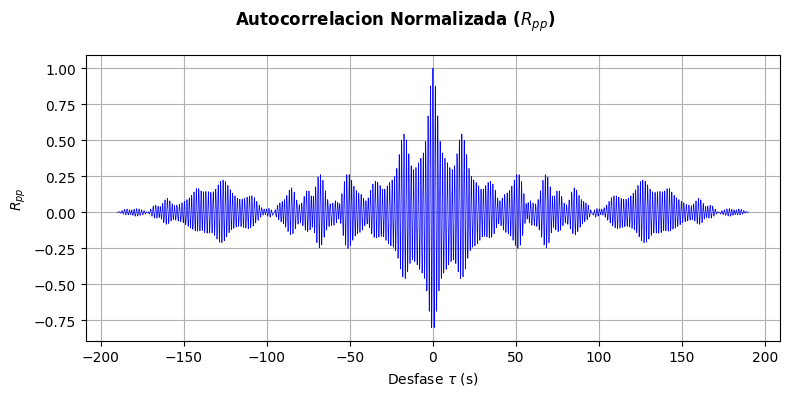

In [5]:
tensor_r, lags, fig = imta.autocorrelacion_norm(
    p1_fluc['fluc'], frecuencia=100, plot=True, max_lag_seg=200)

tensor_r, lags, fig = imta.autocorrelacion_norm(
    p2_fluc['fluc'], frecuencia=100, plot=True, max_lag_seg=200)

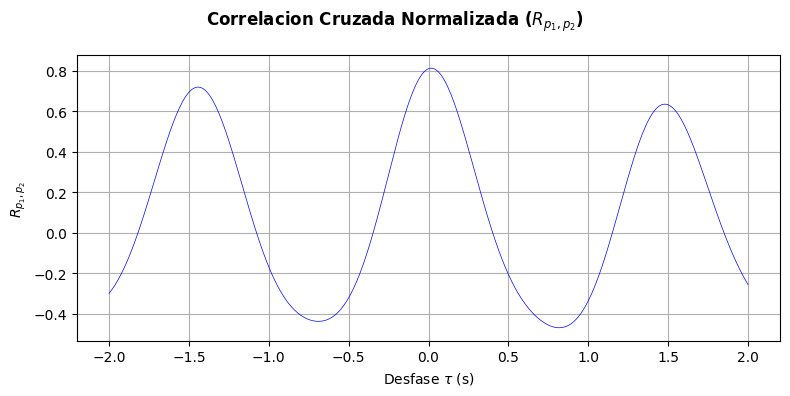

In [12]:
tensor_r, lags, fig = imta.correlacion_cruzada_norm(
    p1_fluc['fluc'], p2_fluc['fluc'], frecuencia=100, plot=True, max_lag_seg=2)

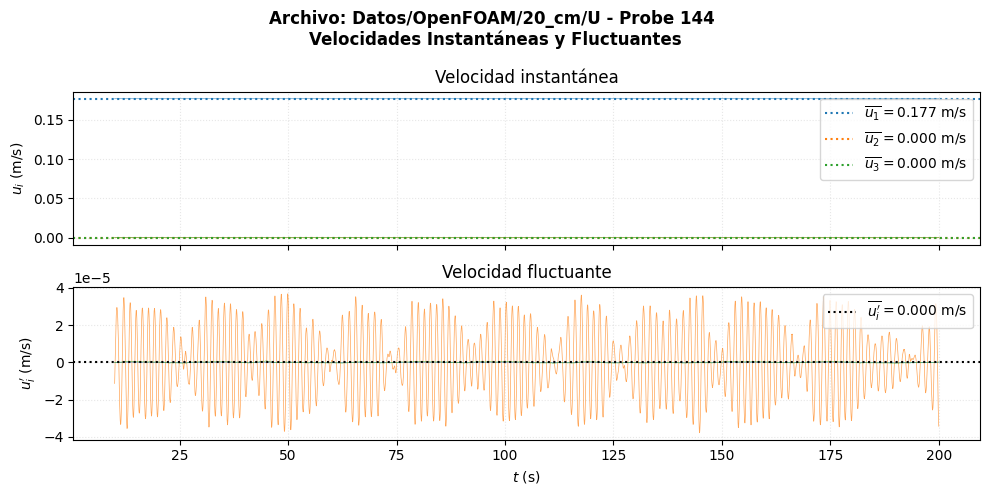

In [7]:
probe_1 = 144
# Proceso de velocidad
u1_a, u2_a, u3_a, tU_a, dfU_a = imta.recortar_tiempo(U_probes, probe=probe_1, inicio=inicio)
u1_fluc, _ = imta.fluctuante(u1_a, tiempo=tU_a)
u2_fluc, _ = imta.fluctuante(u2_a, tiempo=tU_a)
u3_fluc, _ = imta.fluctuante(u3_a, tiempo=tU_a)

imta.plot_ui(tU_a, u1_fluc, u2_fluc, u3_fluc,
            titulo=f'Archivo: {file_U} - Probe {probe_1} \nVelocidades Instantáneas y Fluctuantes',
            etiquetas=('u_1', 'u_2', 'u_3'));

In [8]:
# Creación de vector con ángulos
angulos_deg = np.arange(0, 360, 10)
angulos_rad = np.radians(angulos_deg) # Conversión a radianes
dtheta = angulos_rad[1]-angulos_rad[0] # Paso de ángulo

num_cil = 2 
allprobes = np.arange(0, num_cil, 1) 

# Iniciar el diccionario vacío
cilindros = {}

for probe_i in allprobes:
    puntos_i = list(range(probe_i * angulos_deg.size, (probe_i + 1) * angulos_deg.size))
    
    # Guardar lista en el diccionario usando probe_i como índice
    cilindros[probe_i] = puntos_i

#Prueba
print("Puntos del cilindro 1:")
print(cilindros[0])
print("Puntos del cilindro -1:")
print(cilindros[num_cil-1])

Puntos del cilindro 1:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Puntos del cilindro -1:
[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]


In [9]:
# Datos de: p_inf
print('Presión en el infinito (media)')
print(f'P_(inf) = {(np.mean(p_probes[144])*rho):2f} Pa')
# Datos de: u_inf
print('Velocidad en el infinito (media)')
print(f'U_(inf) = {(np.mean(U_probes[144])):2f} m/s')

Presión en el infinito (media)
P_(inf) = 2.698326 Pa
Velocidad en el infinito (media)
U_(inf) = 0.059054 m/s


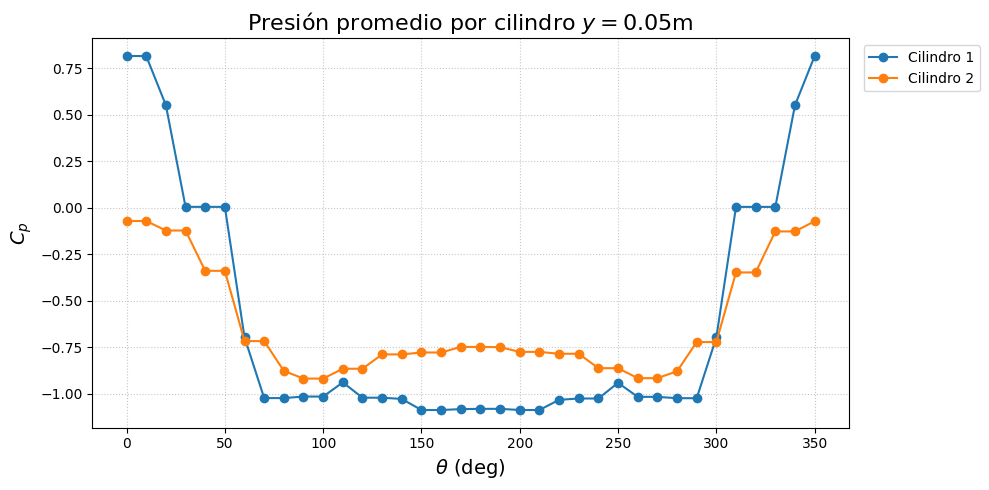

In [10]:
# Plano de 0.020 [Cilindro 1 al 20]
U_inf = 0.177  # m/s
p_inf = 2.968326 # Pa

Cp_teorico = 1 - 4 * (np.sin(angulos_rad)**2)

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

#plt.plot(angulos_deg, Cp_teorico, 'k:', linewidth=1.5, label='Flujo Potencial (Teórico)')

# # Para todas probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [0, 1] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
     plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.05 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

Velocidad exterior = 0.177 m/s
Altura = 0.1 m

Cilindro         Fd_mean (N)    Fl_mean (N)    CD_mean    CL_mean
----------------------------------------------------------------
Cilindro 1          -0.094195      -0.000114   -1.20265   -0.00145
Cilindro 2          -0.040125      -0.000074   -0.51230   -0.00095


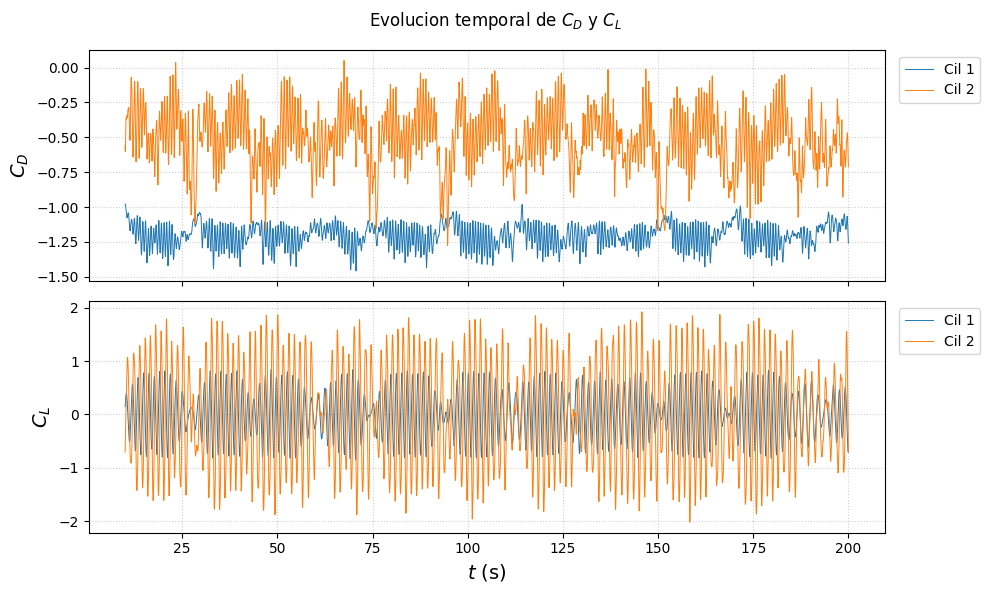

In [11]:
# Parametros 
span = 0.10     # m (Envergadura o altura de la pila)
D = 0.05        # m (Diámetro de los cilindros)
R = D / 2       # m (Radio de los cilindros)

# Extraer presion y calcular CD, CL por cada cilindro
CD = {}
CL = {}
Fx = {}
Fz = {}
p_theta_dict = {}

for i in cilindros.keys():
    p_theta_i, t_i = imta.extraer_p_theta(p_probes, cilindros[i], t_inicio=inicio)
    p_theta_dict[i] = p_theta_i
    CD[i], CL[i], Fx[i], Fz[i] = imta.cd_cl_integrando_p(p_theta_i, angulos_rad, rho, U_inf, R, D, span)

# === Graficas de CD y CL para cilindros seleccionados ===
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

print(f"Velocidad exterior = {U_inf} m/s")
print(f"Altura = {span} m")
print(f"{'\nCilindro':<14} {'Fd_mean (N)':>14} {'Fl_mean (N)':>14} {'CD_mean':>10} {'CL_mean':>10}")
print("-" * 64)

for i in cilindros_a_graficar:
    ax[0].plot(t_i, CD[i], linewidth=0.7, label=f'Cil {i+1}')
    ax[1].plot(t_i, CL[i], linewidth=0.7, label=f'Cil {i+1}')
    print(f"{'Cilindro ' + str(i+1):<14} "
    f"{np.mean(Fx[i]):>14.6f} "
    f"{np.mean(Fz[i]):>14.6f} "
    f"{np.mean(CD[i]):>10.5f} "
    f"{np.mean(CL[i]):>10.5f}")

# Panel superior: CD
ax[0].set_ylabel(r'$C_D$', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Panel inferior: CL
ax[1].set_ylabel(r'$C_L$', fontsize=14)
ax[1].set_xlabel(r'$t$ (s)', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(r'Evolucion temporal de $C_D$ y $C_L$')
plt.tight_layout()